<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17.1.4_SLR_Residuals_and_Model_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Residuals and Model Assessment

Author: Brad Sheese

___

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


## What Are Residuals?
Back in 17.1.1, when you built a regression model from scratch, you computed the difference between each observed sweetness value and the value your model predicted. We called those differences "residuals."

Now we are going to make residuals the main focus, because residual analysis is the single most important diagnostic tool for assessing whether a linear model is effectively modelling our data.

Every fitted regression model produces residuals. They represent the leftover variation in the data that the model did not capture.

The fundamental decomposition is:

$$\text{Data} = \text{Fit} + \text{Residual}$$

In other words, each observed data point can be broken into two parts. The fit is the value the model predicted, which is the point on the regression line. The residual is the difference between what you observed and what the model predicted.

A positive residual means the model underpredicted, so the actual value was above the line. A negative residual means the model overpredicted, so the actual value was below the line. A good model has residuals that are as small as possible.

### Formal Definition

The residual for the $i$-th observation is:
$$e_i = y_i - \hat{y}_i$$

Where $y_i$ is the observed outcome value and $\hat{y}_i$ is the predicted outcome value, which is the point on the regression line.

The least squares line is specifically chosen to minimize the sum of squared residuals.

### Visualizing Residuals on a Scatterplot

Let us create a small dataset and see what residuals look like visually. Each residual is the vertical distance from an observed point to the regression line.

/tmp/ipykernel_1908/702789770.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


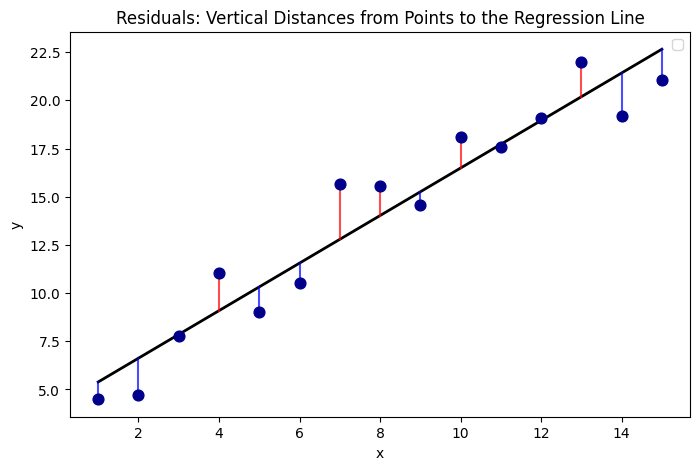

Red lines = positive residuals (model underpredicted)
Blue lines = negative residuals (model overpredicted)


In [17]:
# Fabricate a small dataset with a clear linear trend
np.random.seed(42)
n = 15
x_demo = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
y_demo = 2 + 1.5 * x_demo + np.random.normal(0, 2, n)

# Fit the model
X_demo = x_demo.reshape(-1, 1)
model_demo = LinearRegression().fit(X_demo, y_demo)
y_pred_demo = model_demo.predict(X_demo)
residuals_demo = y_demo - y_pred_demo

# Create the visualization,
# NOTE: you do note need to know how this visualization code works
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_demo, y_demo, s=60, color='darkblue', zorder=5)
ax.plot(x_demo, y_pred_demo, color='black', linewidth=2)

# Draw residual lines
for i in range(n):
    color = 'red' if residuals_demo[i] > 0 else 'blue'
    ax.plot([x_demo[i], x_demo[i]], [y_demo[i], y_pred_demo[i]],
            color=color, linewidth=1.5, alpha=0.7)

# # Annotate a few points
# for i in [0, 5, 10]:
#     ax.annotate('e = {:.1f}'.format(residuals_demo[i]),
#                 xy=(x_demo[i], (y_demo[i] + y_pred_demo[i]) / 2),
#                 xytext=(x_demo[i] + 0.3, (y_demo[i] + y_pred_demo[i]) / 2),
#                 fontsize=9, color='red' if residuals_demo[i] > 0 else 'blue')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Residuals: Vertical Distances from Points to the Regression Line')
ax.legend()
plt.show()

print("Red lines = positive residuals (model underpredicted)")
print("Blue lines = negative residuals (model overpredicted)")


## The Residual Plot
A scatterplot with a regression line is useful, but it can be hard to see subtle patterns in the residuals when they are overlaid on the data. A residual plot isolates the residuals and displays them on their own.

A residual plot shows the predictor values or the predicted values on the x-axis, the residual values on the y-axis, and a dashed reference line at residual equal to zero.

Conceptually, a residual plot is like tipping the scatterplot over so the regression line is horizontal.

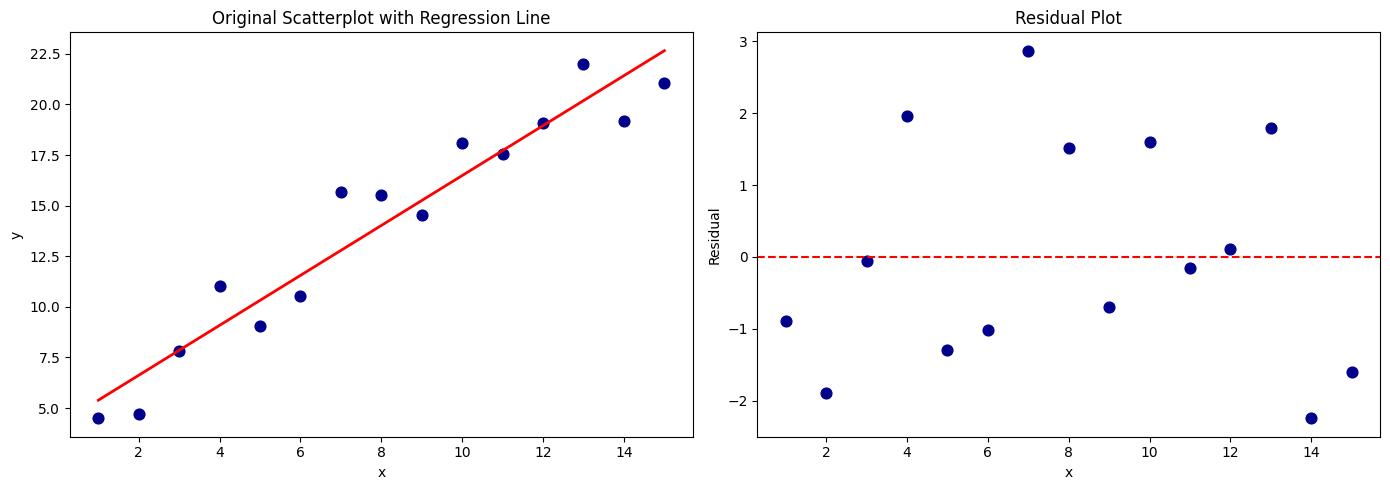

In [3]:
# Create residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: original scatterplot with regression line
axes[0].scatter(x_demo, y_demo, s=60, color='darkblue')
axes[0].plot(x_demo, y_pred_demo, color='red', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Original Scatterplot with Regression Line')

# Right: residual plot
axes[1].scatter(x_demo, residuals_demo, s=60, color='darkblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


### Why Residual Plots Are Powerful
Residual plots amplify patterns. A slight curve in the scatterplot becomes an obvious curve in the residual plot. They remove the dominant trend, so by subtracting the linear fit we can see what is left. They make outliers obvious, because extreme residuals stand out clearly against the reference line at zero. And they reveal non-constant variance, since a fan or funnel shape is easy to spot.

The key principle is simple. What we want to see is random noise scattered around zero, with no systematic pattern. What we do not want to see is any systematic pattern, such as curves, funnels, or clusters.

In [4]:
# TO DO: Make visuaizations of residual plots that show curves, funnels, clusters

### Two Types of Residual Plots

For simple linear regression, there are two common choices for the x-axis. The first is residual versus predictor, where the x-axis is the original x values. This is the most common and easiest to interpret, and it directly shows whether residuals vary with the predictor.

The second is residual versus fitted, where the x-axis is the predicted y values. This is equivalent to residual versus predictor in simple linear regression, since the predicted values are a linear function of x. It becomes more useful in multiple regression where there are multiple predictors.For simple linear regression, both tell the same story. Let us verify.

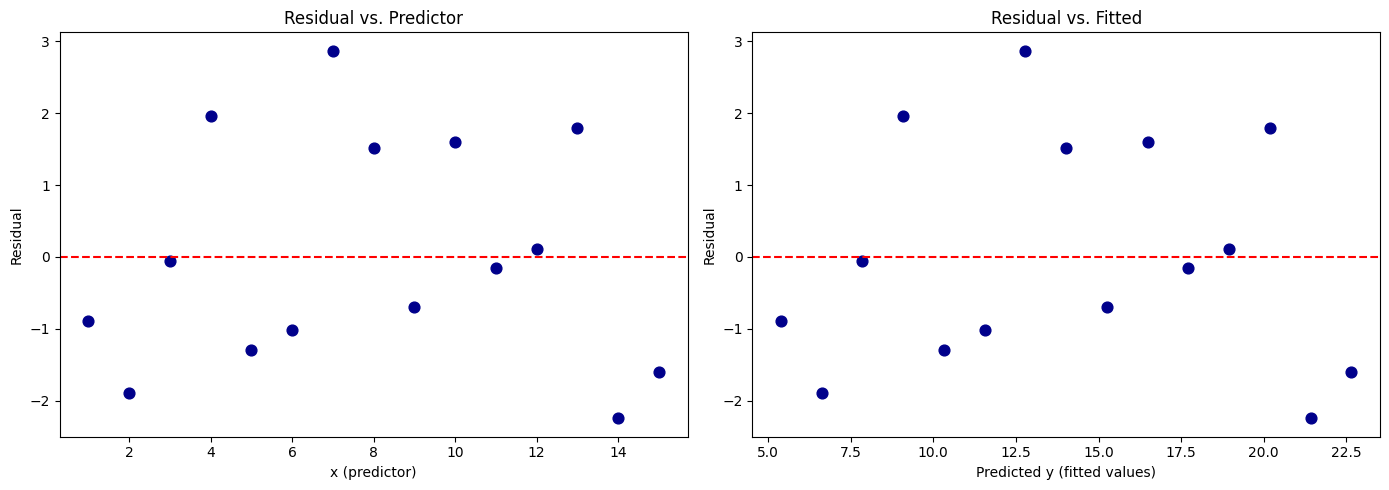

For simple linear regression, both plots show the same pattern.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual vs. predictor
axes[0].scatter(x_demo, residuals_demo, s=60, color='darkblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('x (predictor)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residual vs. Predictor')

# Residual vs. fitted
axes[1].scatter(y_pred_demo, residuals_demo, s=60, color='darkblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted y (fitted values)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual vs. Fitted')

plt.tight_layout()
plt.show()

print("For simple linear regression, both plots show the same pattern.")


### What to Look For
After fitting any linear model, create a residual plot and ask yourself a few questions.

* Do the residuals look like random noise around zero? If so, the linear model is appropriate.
* Is there a curved pattern? If so, the relationship is non-linear and a straight line is not the right model.
* Do the residuals fan out, with wider spread at one end? If so, the variance is not constant and predictions are more uncertain in some regions.
* Are there individual points far from the rest? If so, those are potential outliers that deserve investigation.

## Diagnosing Residual Patterns
Now let us look at three different datasets, each with a different underlying relationship. We will fit a straight line to each and examine the residual plots to see what they tell us.

### Dataset A: Linear Relationship
This dataset has a genuine linear relationship with random noise added. Let us see what the residual plot looks like when the model is appropriate.

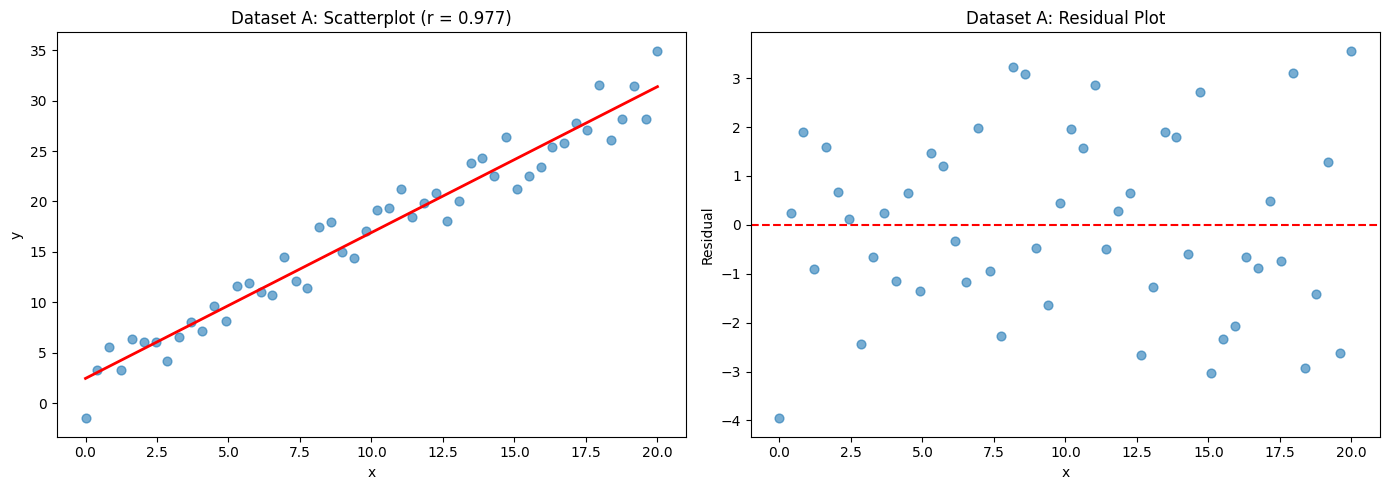

R-squared: 0.9547
Residual std: 1.86


In [6]:
# Dataset A: linear + noise
np.random.seed(100)
n = 50
xA = np.linspace(0, 20, n)
yA = 2 + 1.5 * xA + np.random.normal(0, 2, n)

# Fit model
XA = xA.reshape(-1, 1)
modelA = LinearRegression().fit(XA, yA)
y_pred_A = modelA.predict(XA)
resid_A = yA - y_pred_A

# Side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(xA, yA, alpha=0.6, s=40)
axes[0].plot(xA, y_pred_A, color='red', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Dataset A: Scatterplot (r = {:.3f})'.format(np.corrcoef(xA, yA)[0,1]))

axes[1].scatter(xA, resid_A, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')
axes[1].set_title('Dataset A: Residual Plot')

plt.tight_layout()
plt.show()

print("R-squared: {:.4f}".format(modelA.score(XA, yA)))
print("Residual std: {:.2f}".format(resid_A.std()))


### Interpretation: Dataset A
The residuals show no obvious pattern. They are scattered randomly around zero with roughly equal spread across the range of x. This is exactly what we want to see. A linear model is appropriate here.

The coefficient of determination tells us how much variation the model explains, and the residual plot confirms that what is left over is just random noise.

### Dataset B: Curved Relationship
This dataset has a quadratic relationship. Let us see what happens when we fit a straight line to curved data.

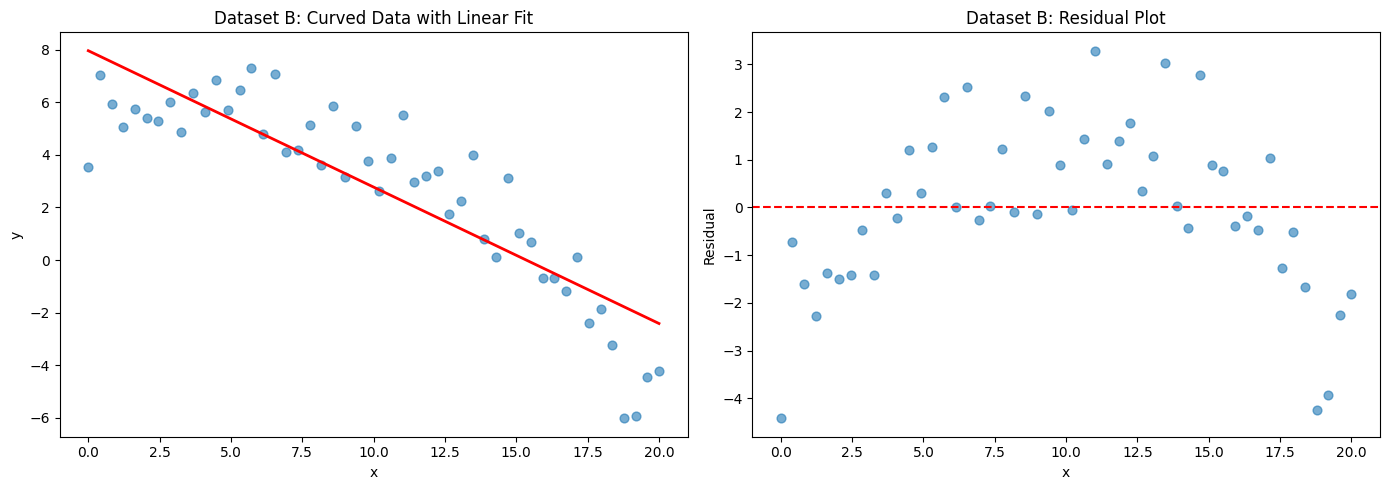

R-squared (linear model): 0.7578
Residual std: 1.73


In [7]:
# Dataset B: quadratic + noise
np.random.seed(200)
xB = np.linspace(0, 20, n)
yB = 5 + 0.3 * xB - 0.04 * xB**2 + np.random.normal(0, 1, n)

# Fit a straight line (wrong model!)
XB = xB.reshape(-1, 1)
modelB = LinearRegression().fit(XB, yB)
y_pred_B = modelB.predict(XB)
resid_B = yB - y_pred_B

# Side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(xB, yB, alpha=0.6, s=40)
axes[0].plot(xB, y_pred_B, color='red', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Dataset B: Curved Data with Linear Fit')

axes[1].scatter(xB, resid_B, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')
axes[1].set_title('Dataset B: Residual Plot')

plt.tight_layout()
plt.show()

print("R-squared (linear model): {:.4f}".format(modelB.score(XB, yB)))
print("Residual std: {:.2f}".format(resid_B.std()))


### Interpretation: Dataset B
The residuals show a clear curved pattern. They are positive at low x, negative in the middle, and positive at high x. This U-shaped pattern in the residuals tells us the straight line is systematically missing a curved relationship. A linear model is not appropriate here.When you see this pattern, you could transform the predictor, use a polynomial regression model, or apply a variable transformation such as log or square root.

### Dataset C: No Relationship

This dataset has two completely uncorrelated variables. Let us see what the residual plot looks like.

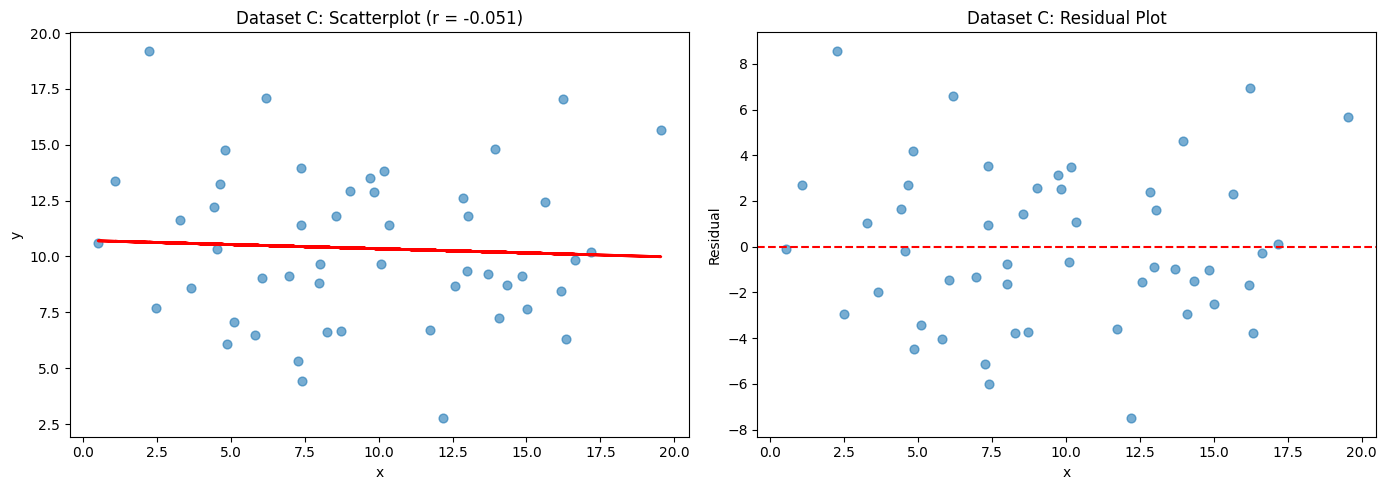

Slope: -0.0374
R-squared: 0.0027
Residual std: 3.43


In [8]:
# Dataset C: no relationship (independent variables)
np.random.seed(300)
xC = np.random.uniform(0, 20, n)
yC = np.random.normal(10, 3, n)

# Fit model
XC = xC.reshape(-1, 1)
modelC = LinearRegression().fit(XC, yC)
y_pred_C = modelC.predict(XC)
resid_C = yC - y_pred_C

# Side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(xC, yC, alpha=0.6, s=40)
axes[0].plot(xC, y_pred_C, color='red', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Dataset C: Scatterplot (r = {:.3f})'.format(np.corrcoef(xC, yC)[0,1]))

axes[1].scatter(xC, resid_C, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')
axes[1].set_title('Dataset C: Residual Plot')

plt.tight_layout()
plt.show()

print("Slope: {:.4f}".format(modelC.coef_[0]))
print("R-squared: {:.4f}".format(modelC.score(XC, yC)))
print("Residual std: {:.2f}".format(resid_C.std()))


### Interpretation: Dataset C
The residuals show no pattern. They look like random noise around zero. But notice the slope is essentially zero and R-squared is near zero. The best line is nearly flat, meaning x provides no useful information for predicting y.

A linear model is technically valid but useless. It is just predicting the mean of y for every x. This is an important distinction. A clean residual plot does not mean the model is good. It just means the linear form is appropriate. If the slope is zero, the linear form is appropriate but the predictor is uninformative.

### Summary: Three Residual Patterns| Pattern | Residual Plot Looks Like | Verdict | Action ||---|---|---|---|| Random scatter around 0 | Cloud of points, no structure | Linear model appropriate | Proceed || Curved or U-shaped | Systematic curve | Linear model not appropriate | Transform variables or use non-linear model || No pattern, flat line | Cloud around 0, slope near 0 | Linear model valid but useless | Consider different predictors |The residual plot is your first diagnostic check after fitting any linear model.

## Additional Residual Plot Diagnostics
Beyond the three basic patterns above, there are two more things to look for in residual plots.

### Heteroscedasticity
Sometimes the spread of the residuals changes systematically with the predictor. This is called heteroscedasticity. The variance of the errors is not constant. A common pattern is a funnel or fan shape, where residuals are tightly clustered at low x values and spread out at high x values, or vice versa.This does not mean the linear trend is wrong, but it means the model predictions are more uncertain in some regions than others. This affects confidence intervals and hypothesis tests.

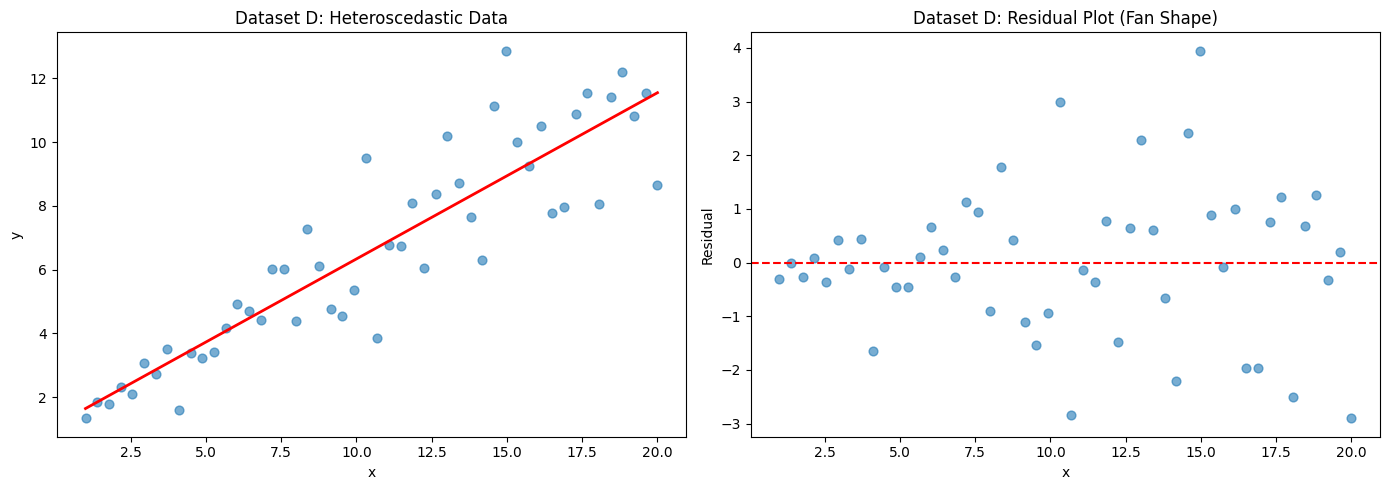

Notice: the residuals fan out as x increases.
The model predictions are more uncertain for larger x values.


In [9]:
# Dataset D: heteroscedastic
np.random.seed(400)
xD = np.linspace(1, 20, n)
yD = 1 + 0.5 * xD + np.random.normal(0, 0.15 * xD, n)

# Fit model
XD = xD.reshape(-1, 1)
modelD = LinearRegression().fit(XD, yD)
y_pred_D = modelD.predict(XD)
resid_D = yD - y_pred_D

# Side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(xD, yD, alpha=0.6, s=40)
axes[0].plot(xD, y_pred_D, color='red', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Dataset D: Heteroscedastic Data')

axes[1].scatter(xD, resid_D, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')
axes[1].set_title('Dataset D: Residual Plot (Fan Shape)')

plt.tight_layout()
plt.show()

print("Notice: the residuals fan out as x increases.")
print("The model predictions are more uncertain for larger x values.")


### Interpretation: Heteroscedasticity
The residuals fan out as x increases. The linear trend may still be correct, since the red line goes through the middle of the cloud, but the assumption of constant variance is violated.A real-world example is predicting income from years of education. People with more education have a wider range of possible incomes than people with less education. The average relationship may be linear, but the uncertainty grows with education.The linear model can still be used for predictions, but confidence intervals will be unreliable. Transformations, such as taking the log of the outcome, can sometimes stabilize the variance.

### Outliers in the Residual Plot

An outlier is an observation with an unusually large residual. In the residual plot, it appears as a single point far from the rest. Let us add an outlier to our linear dataset and see how it shows up.

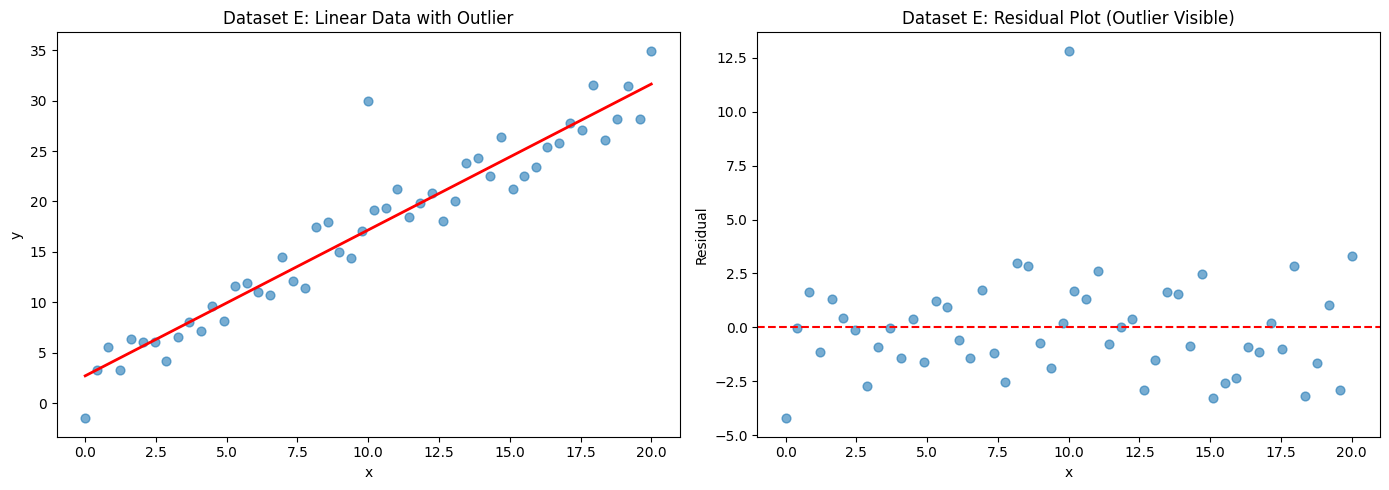

Outlier residual: 12.8
Other residuals range: -4.2 to 3.3


In [10]:
# Dataset E: linear + one outlier
xE = xA.copy()
yE = yA.copy()
xE = np.append(xE, 10)
yE = np.append(yE, 30)

# Fit model
XE = xE.reshape(-1, 1)
modelE = LinearRegression().fit(XE, yE)
y_pred_E = modelE.predict(XE)
resid_E = yE - y_pred_E

# Side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(xE, yE, alpha=0.6, s=40)
axes[0].plot(np.sort(xE), y_pred_E[np.argsort(xE)], color='red', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Dataset E: Linear Data with Outlier')

axes[1].scatter(xE, resid_E, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')
axes[1].set_title('Dataset E: Residual Plot (Outlier Visible)')

plt.tight_layout()
plt.show()

print("Outlier residual: {:.1f}".format(resid_E[-1]))
print("Other residuals range: {:.1f} to {:.1f}".format(resid_E[:-1].min(), resid_E[:-1].max()))


### Interpretation: Outliers
The outlier appears as a single point far from the rest in the residual plot. It is much easier to spot here than in the scatterplot, where it blends in with the cloud of points.When you find an outlier, check for data entry errors. Investigate whether it is a special case with an interesting explanation. Run the analysis both with and without the outlier. Report both results and discuss the difference.

We will cover outliers, leverage points, and influential points in more detail in 17.1.6.

## Practice: Mystery Residual Plots
Below are three residual plots without their corresponding scatterplots. For each one, try to diagnose what the original data looks like before revealing the answer.

Ask yourself whether there is a pattern or random noise. If there is a pattern, what shape is it? Is the spread constant, or does it change? Are there any extreme points?

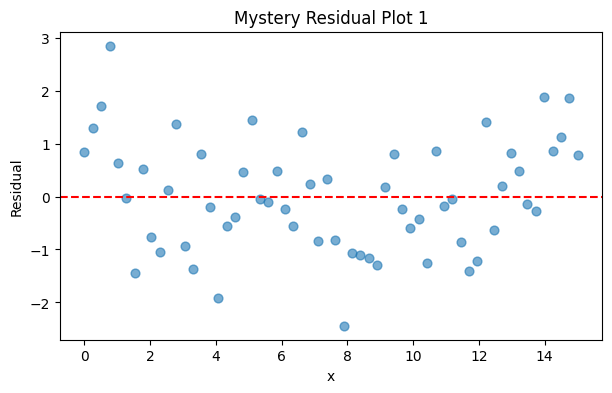

DIAGNOSIS: What pattern do you see?
What does this tell you about the original relationship?

Scroll down for the answer...


In [11]:
# Mystery Residual Plot 1
np.random.seed(500)
n_m = 60
x_m1 = np.linspace(0, 15, n_m)
y_m1 = np.exp(0.15 * x_m1) + np.random.normal(0, 1, n_m)
X_m1 = x_m1.reshape(-1, 1)
model_m1 = LinearRegression().fit(X_m1, y_m1)
resid_m1 = y_m1 - model_m1.predict(X_m1)

plt.figure(figsize=(7, 4))
plt.scatter(x_m1, resid_m1, alpha=0.6, s=40)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('x')
plt.ylabel('Residual')
plt.title('Mystery Residual Plot 1')
plt.show()

print("DIAGNOSIS: What pattern do you see?")
print("What does this tell you about the original relationship?")
print()
print("Scroll down for the answer...")


### Answer: Mystery Plot 1
The residuals show a curved pattern. This indicates the original data has a non-linear relationship, in this case exponential growth, that a straight line cannot capture. A linear model is not appropriate.

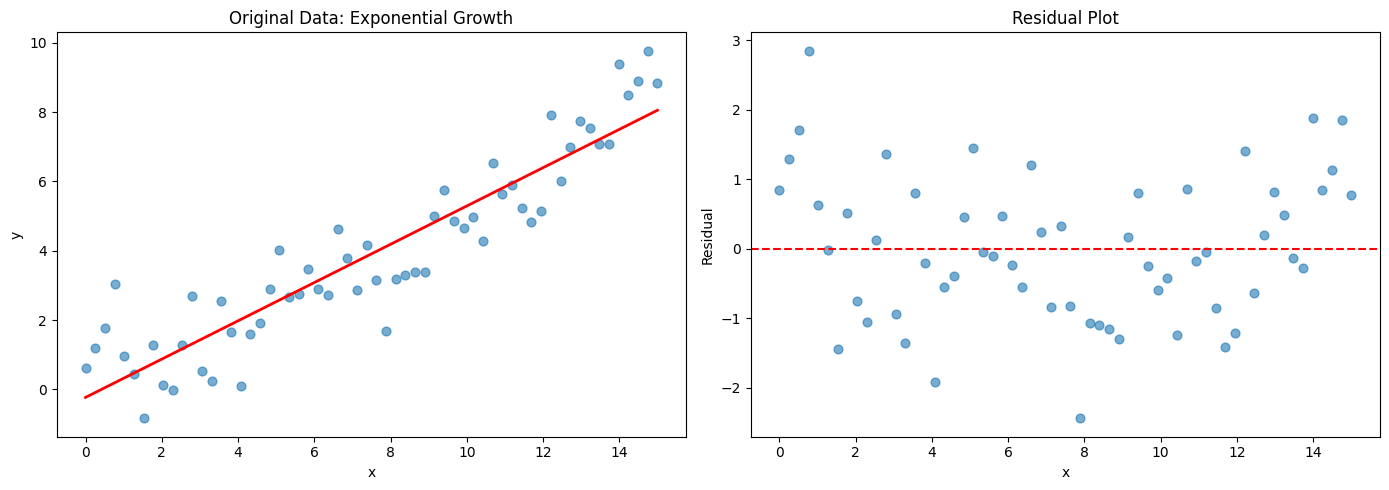

In [12]:
# Reveal the original scatterplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x_m1, y_m1, alpha=0.6, s=40)
x_smooth = np.linspace(0, 15, 100)
axes[0].plot(x_smooth, model_m1.predict(x_smooth.reshape(-1, 1)), color='red', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Original Data: Exponential Growth')

axes[1].scatter(x_m1, resid_m1, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


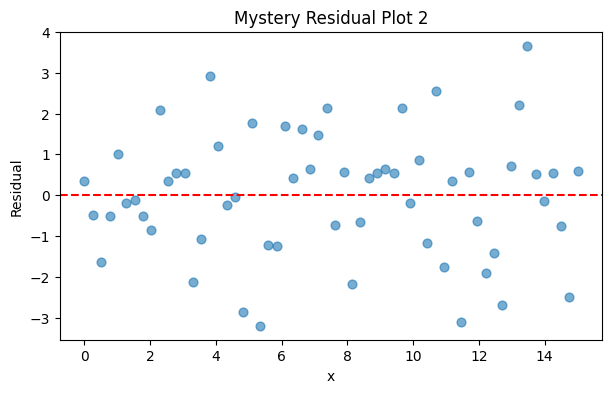

DIAGNOSIS: What pattern do you see?
Is a linear model appropriate here?

Scroll down for the answer...


In [13]:
# Mystery Residual Plot 2
np.random.seed(600)
x_m2 = np.linspace(0, 15, n_m)
y_m2 = 3 + 0.8 * x_m2 + np.random.normal(0, 1.5, n_m)
X_m2 = x_m2.reshape(-1, 1)
model_m2 = LinearRegression().fit(X_m2, y_m2)
resid_m2 = y_m2 - model_m2.predict(X_m2)

plt.figure(figsize=(7, 4))
plt.scatter(x_m2, resid_m2, alpha=0.6, s=40)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('x')
plt.ylabel('Residual')
plt.title('Mystery Residual Plot 2')
plt.show()

print("DIAGNOSIS: What pattern do you see?")
print("Is a linear model appropriate here?")
print()
print("Scroll down for the answer...")


### Answer: Mystery Plot 2
The residuals show no pattern. They are randomly scattered around zero with roughly constant spread. This is exactly what we want. A linear model is appropriate.

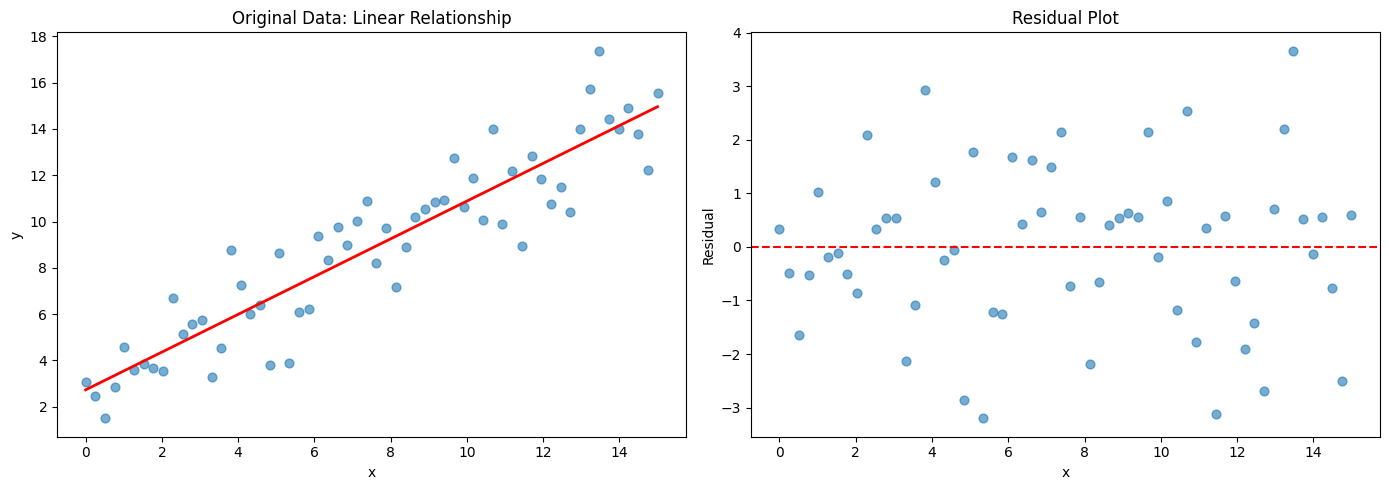

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x_m2, y_m2, alpha=0.6, s=40)
axes[0].plot(x_m2, model_m2.predict(X_m2), color='red', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Original Data: Linear Relationship')

axes[1].scatter(x_m2, resid_m2, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


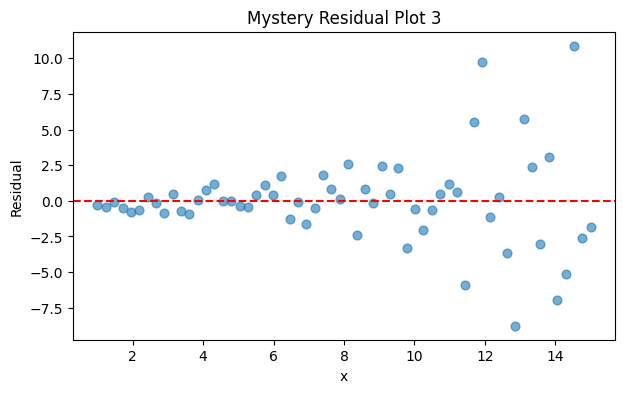

DIAGNOSIS: What pattern do you see?
Is the variance constant?

Scroll down for the answer...


In [15]:
# Mystery Residual Plot 3
np.random.seed(700)
x_m3 = np.linspace(1, 15, n_m)
y_m3 = 2 + 0.5 * x_m3 + np.random.normal(0, 0.1 * x_m3**1.5, n_m)
X_m3 = x_m3.reshape(-1, 1)
model_m3 = LinearRegression().fit(X_m3, y_m3)
resid_m3 = y_m3 - model_m3.predict(X_m3)

plt.figure(figsize=(7, 4))
plt.scatter(x_m3, resid_m3, alpha=0.6, s=40)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('x')
plt.ylabel('Residual')
plt.title('Mystery Residual Plot 3')
plt.show()

print("DIAGNOSIS: What pattern do you see?")
print("Is the variance constant?")
print()
print("Scroll down for the answer...")


### Answer: Mystery Plot 3
The residuals show no curved pattern, but the spread clearly increases with x. This is a funnel shape. This is heteroscedasticity, which means non-constant variance. The linear trend may be correct, but the model predictions are increasingly uncertain at higher x values.

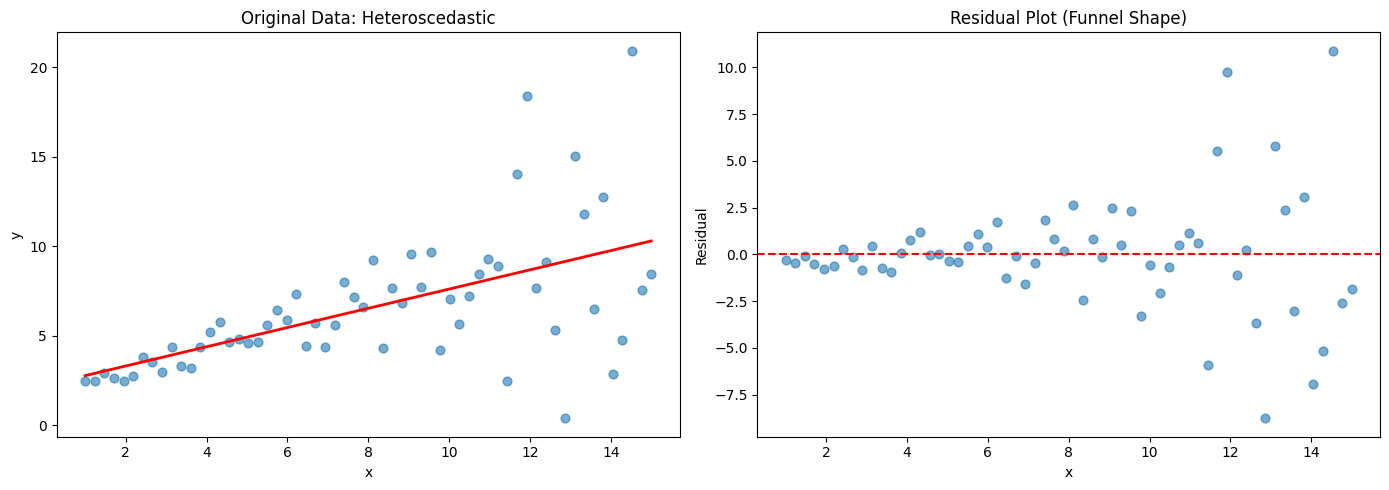

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x_m3, y_m3, alpha=0.6, s=40)
axes[0].plot(x_m3, model_m3.predict(X_m3), color='red', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Original Data: Heteroscedastic')

axes[1].scatter(x_m3, resid_m3, alpha=0.6, s=40)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot (Funnel Shape)')

plt.tight_layout()
plt.show()


## The Residual Analysis Workflow
After fitting any linear model, follow this checklist. Fit the model. Compute the residuals. Create a residual plot, comparing residuals against the predictor or the fitted values. Look for patterns. Random scatter means you are good to go. Curvature means a non-linear relationship, so consider transforming variables. A funnel shape means non-constant variance, so consider a log transform. Extreme points mean potential outliers, so investigate. Then decide whether to proceed with the model, transform variables, or reconsider the approach.